In [1]:
# Customer Churn Analysis

### Objective
# Analyze customer demographics, subscription behavior, and support interactions 
# to identify factors contributing to customer churn and generate actionable business insights.

In [2]:
# 1) Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("SQLite:", sqlite3.sqlite_version)

print("✅ All libraries imported successfully!")

NumPy: 2.5.1
Pandas: 3.0.3
Matplotlib: 3.11.1
Seaborn: 0.13.2
SQLite: 3.50.4
✅ All libraries imported successfully!


In [3]:
# 1) import database / data

In [4]:
# Connect to the SQLite database
# Objective: Establish a connection between Python and the SQLite database so that we can retrieve customer data using SQL queries.

conn = sqlite3.connect("customer_churn.db")

# SQL query to get all table names
sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

# Read table names into a DataFrame
tables = pd.read_sql(sql_query, conn)

# Create a DataFrame for each table
for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

# Close the connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [5]:
# Load Tables into Pandas
# Objective: Read each table from the SQLite database and convert it into a Pandas DataFrame for further analysis.

# Print table names and column names

conn = sqlite3.connect("customer_churn.db")

for table_name in tables["name"]:
    print(f"\nTable Name: {table_name}")

    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)

    print("Columns:")
    print(columns["name"].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [6]:
# To see the complete dataset during analysis. 

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [7]:
# 2) Data Cleaning

In [8]:
# Database cleaning - Customer Table

# Explore Database Schema
# Objective: Inspect each table to understand its column names and overall structure before starting data cleaning and analysis.

# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [9]:
# Inspect Dataset Structure
# Objective: Understand the dataset by examining the number of rows, columns, data types, and missing values. 
# This step helps identify data quality issues before cleaning.
    
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [10]:
# a. rename col - name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values - country

In [11]:
# a. Rename column 'name' to 'customer_name'

df_db_customer.rename(
    columns={"name": "customer_name"},
    inplace=True)


In [12]:
# b. Drop columns: interests and pincode

df_db_customer.drop(columns=["interests", "pincode"], inplace=True)

In [13]:
# c. Convert 'dob' column datatype to datetime

df_db_customer["dob"] = pd.to_datetime(df_db_customer["dob"])

In [14]:
# d. data standardization - gender

# df_db_customer["gender"].unique()

df_db_customer["gender"] = df_db_customer["gender"].replace({
    "Men": "Male",
    "Women": "Female"
})


In [15]:
# e. fix missing values - country
# this shows rows which have country name missing:
df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [16]:
# df_db_customer[["country", "state"]]

# country and state - unique value pair
# Create a mapping of state -> country

state_country_mapping = (
    df_db_customer
    .dropna(subset=["country"])
    .set_index("state")["country"]
    .to_dict()
)

# Fill missing country values using the mapping

df_db_customer["country"] = df_db_customer["country"].fillna(
    df_db_customer["state"].map(state_country_mapping)
)

In [17]:
## Data Cleaning Summary - Customer Table

# The following data cleaning steps were performed on the customer dataset:

# 1. Renamed the `name` column to `customer_name` for better readability.
# 2. Removed the `interests` column because it contained a high percentage of missing values.
# 3. Removed the `pincode` column because it contained 100% missing values.
# 4. Converted the `dob` column from string to datetime format.
# 5. Standardized the `gender` column by replacing inconsistent values (`Men` → `Male` and `Women` → `Female`).
# 6. Filled missing values in the `country` column using the corresponding state-to-country mapping.

# The customer dataset is now cleaned and ready for analysis.

In [18]:
# Data Cleaning - Subscription Table

In [19]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [20]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [21]:
# a. convert below mentioned column datatype to datetime:
# subscription_start_date
# renewal_date
# cancellation_date

# b. change Refferal to Referral

In [22]:
# a. Datatype change 

#List of date columns 
# Using a list of column names allows the same transformation to be applied to multiple columns in a single statement. 
# This makes the code more concise, easier to maintain, and scalable if additional date columns are added in the future.

date_col = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

# Convert all date columns to datetime

df_db_subscription[date_col] = (
    df_db_subscription[date_col]
    .apply(pd.to_datetime)
)

In [23]:
# df_db_subscription["subscription_type"].unique()

# Replace incorrect spelling

df_db_subscription["subscription_type"] = (
    df_db_subscription["subscription_type"]
    .replace({"Refferal": "Referral"})
)

In [24]:
## Data Cleaning Summary - Subscription Table

# The following data cleaning steps were performed on the subscription dataset:

# 1. Converted all date columns (`subscription_start_date`, `renewal_date`, and `cancellation_date`) to datetime format.
# 2. Corrected the spelling inconsistency in the `subscription_type` column by replacing `Refferal` with `Referral`.
# 3. Reviewed missing values in `cancellation_date` and `cancellation_reason`. These missing values were retained because they indicate customers who have not cancelled their subscriptions.

# The subscription dataset is now cleaned and ready for analysis.

In [25]:
# Data Cleaning - Support Table

# Prepare the support dataset for analysis.

In [26]:
# preview the dataset

df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [27]:
# Dataset information

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [28]:
# a. drop column col_1 and comment

df_db_support.drop(columns=['col_1', 'comment'], inplace = True)

In [29]:
# b. change datatype for complaint_date

date_col = ["complaint_date"]

# Convert all date columns to datetime

df_db_support[date_col] = (
    df_db_support[date_col]
    .apply(pd.to_datetime)
)

In [30]:
# Data Cleaning Summary - Support Table

# The following data cleaning steps were performed on the support dataset:

#1. Converted the `complaint_date` column from string to datetime format.
#2. Removed the `col_1` column because it contained 100% missing values.
#3. Reviewed the `comment` column and retained it because it may provide useful qualitative insights into customer complaints.
#4. Verified that the `escalations` column contained consistent values.
#5. Confirmed that there were no duplicate records in the dataset.

# The support dataset is now cleaned and ready for analysis.


In [31]:
# 3. Feature Engineering and Data Analysis

In [32]:
# Feature Engineering
# Create new variables to improve customer churn analysis.

In [33]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34


In [34]:
# Create new column using a current column - churn flag

df_db_subscription["churn_flag"] = np.where(
    df_db_subscription["cancellation_date"].notna(),
    1,
    0
)

# Verify the operation we did

df_db_subscription[
    ["customerid", "cancellation_date", "churn_flag"]
].head()

,customerid,cancellation_date,churn_flag
0,0002-ORFBO,NaT,0
1,0003-MKNFE,2024-09-10,1
2,0004-TLHLJ,NaT,0
3,0011-IGKFF,NaT,0
4,0013-EXCHZ,2024-02-28,1


In [35]:
## Merge Datasets
#  Objective
# • Combine the Customer, Subscription, and Support datasets into a single master dataset using the common key (`customerid`).
# • This consolidated dataset will be used for feature engineering, exploratory data analysis (EDA), visualization, and business insights.

#  Interview Note
# • The three datasets were merged using `customerid` as the common key. 
# • A left join was used to retain all customers from the subscription dataset while bringing in customer demographics and support information. 
# • This created a single consolidated dataset for further analysis.

In [36]:
# first fix the duplicates of support table then merge

df = (
    df_db_subscription
    .merge(df_db_customer, on="customerid", how="left")
    .merge(df_db_support, on="customerid", how="left")
)

In [37]:
df_db_subscription.shape

(21, 12)

In [38]:
df.shape

(23, 20)

In [39]:
df_db_subscription['customerid'].nunique()

21

In [40]:
df_db_customer['customerid'].nunique()

21

In [41]:
df_db_support['customerid'].nunique()

7

In [42]:
df_db_support['customerid'].size

9

In [43]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [44]:
# Create complaint count for each customer

df_db_support["complaint_count"] = (
    df_db_support
    .groupby("customerid")["customerid"]
    .transform("count")
)

# Verify complaint count

df_db_support[["customerid", "complaint_count"]].sort_values("customerid")

,customerid,complaint_count
0,0003-MKNFE,2
1,0003-MKNFE,2
2,0013-EXCHZ,1
3,0013-MHZWF,1
4,0013-SMEOE,1
5,0017-IUDMW,1
6,0019-EFAEP,1
7,0022-TCJCI,2
8,0022-TCJCI,2


In [45]:
# Keep latest complaint record for each customer

df_db_support = (
    df_db_support
    .sort_values("complaint_date")
    .drop_duplicates(subset="customerid", keep="last")
)

In [46]:
# Verify one record per customer

print("Shape:", df_db_support.shape)
print("Unique Customer IDs:", df_db_support["customerid"].nunique())
print("Total Rows:", len(df_db_support))

df_db_support

Shape: (7, 5)
Unique Customer IDs: 7
Total Rows: 7


,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [47]:
# • Multiple support interactions existed for some customers. 
# • To create a customer-level analytical dataset, I first engineered a complaint_count feature to preserve complaint history, 
  # then retained only the most recent support record for each customer. 
# • This avoided duplicate rows after merging while preserving important business information.

In [48]:
# Merge df

df = (
    df_db_subscription
    .merge(df_db_customer, on="customerid", how="left")
    .merge(df_db_support, on="customerid", how="left")
)

In [49]:
df.shape

(21, 21)

In [50]:
# Export the cleaned dataset to CSV

df.to_csv("exported_churn_data.csv", index=False)

In [51]:
# Data Analysis

In [52]:
# 1. Churn Rate

churn_rate = df["churn_flag"].mean() * 100

print("Churn Rate =", round(churn_rate, 2), "%")

Churn Rate = 28.57 %


In [53]:
# 2. Retention Rate

retention_rate = 100 - churn_rate

print("Retention Rate = ",round(retention_rate, 2), "%")

Retention Rate =  71.43 %


In [54]:
# 3. Churn Rate by plan type

churn_by_plan = (
    df.groupby("plan_type")["churn_flag"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name = 'churn_rate_pct')
)

# Verification
print(churn_by_plan)

print("Number of Plan Types:", df["plan_type"].nunique())

print(df["plan_type"].value_counts())

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22
Number of Plan Types: 3
plan_type
Standard    9
Premium     7
Basic       5
Name: count, dtype: int64


In [55]:
### Business Insight:

# • Customers on the Basic plan have the highest churn rate (60%), while Premium plan customers have the lowest churn rate (14.29%). 
# • This suggests that customers subscribed to higher-value plans may be more engaged or satisfied, 
  # whereas Basic plan customers are more likely to discontinue their subscriptions.

In [56]:
# 4 a. Churn by State + sum(revenue) + count of users + churn rate %

churn_by_state = (
    df.groupby("state")
      .agg(
          total_customers=("customerid", "count"),
          total_revenue=("monthly_charges", "sum"),
          churn_rate_pct=("churn_flag", lambda x: round(x.mean() * 100, 2))
      )
      .sort_values(by="churn_rate_pct", ascending=False)
      .reset_index()
)

print(churn_by_state)

           state  total_customers  total_revenue  churn_rate_pct
0      Karnataka                2          20.98          100.00
1      Meghalaya                3          42.97           66.67
2      Telangana                2          30.98           50.00
3          Delhi                4          52.96           25.00
4      Kathmandu                2          20.98            0.00
5    Maharashtra                3          50.97            0.00
6       Nagaland                1          22.99            0.00
7      Rajasthan                2          36.98            0.00
8  Uttar Pradesh                2         115.98            0.00


In [57]:
### Business Insight:

# • Karnataka recorded the highest churn rate (100%), followed by Meghalaya (66.67%) and Telangana (50%), 
  # indicating these states require immediate customer retention efforts.
# • Uttar Pradesh generated the highest monthly revenue (115.98) while maintaining a 0% churn rate, 
  # making it the most valuable and stable customer segment.
# • Delhi has the largest customer base (4 customers) among high-population states with a moderate churn rate (25%), 
  # suggesting opportunities to further improve customer retention.

In [58]:
# 4 b. Churn by subscription_type	+ sum(revenue) + count of users + churn rate %

churn_by_subscription = (
    df.groupby("subscription_type")
      .agg(
          total_customers=("customerid", "count"),
          total_revenue=("monthly_charges", "sum"),
          churn_rate_pct=("churn_flag", lambda x: round(x.mean() * 100, 2))
      )
      .sort_values(by="churn_rate_pct", ascending=False)
      .reset_index()
)

print(churn_by_subscription)

  subscription_type  total_customers  total_revenue  churn_rate_pct
0          Referral                6          74.94           83.33
1              Paid                6         174.94           16.67
2           Organic                9         145.91            0.00


In [59]:
### Business Insight:

# • Customers acquired through the **Referral** channel showed the highest churn rate (83.33%), 
  # indicating potential issues with customer quality or post-acquisition engagement.
# • The **Organic** channel achieved a 0% churn rate while contributing the highest customer base (9 customers), 
  # making it the most effective acquisition channel.
# • The **Paid** channel generated the highest revenue (174.94) with a relatively low churn rate (16.67%), 
  # suggesting it attracts high-value and comparatively loyal customers.


# • The referral channel exhibited an exceptionally high churn rate (83.33%), 
  # suggesting the need to review referral incentives, customer onboarding, or the quality of referred customers

In [60]:
# 5. ARPU - Avg Revenue per user

arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [61]:
# 6. Average Customer Tenure

# Current date
today = pd.Timestamp.today()

# Calculate tenure in days
df["tenure_days"] = np.where(
    df["cancellation_date"].notna(),

    # Cancelled customers
    (df["cancellation_date"] - df["subscription_start_date"]).dt.days,

    # Active customers
    (today - df["subscription_start_date"]).dt.days
)

# Average Customer Tenure

avg_tenure = df["tenure_days"].mean()

print("Average Customer Tenure =", round(avg_tenure, 0), "days")

Average Customer Tenure = 1499.0 days


In [62]:
# 7. Customer Age

#Current date
today = pd.Timestamp.today()

# Calculate customer age

df["age"] = ((today - df["dob"]).dt.days // 365)

In [63]:
# 8. Revenue at Risk - Revenue lost from churned customers

revenue_at_risk = (
    df.loc[df["churn_flag"] == 1, "monthly_charges"]
      .sum()
)

print("Revenue at Risk =", round(revenue_at_risk, 2))

# No of churned customers
print("Number of Churned Customers:", df["churn_flag"].sum())

Revenue at Risk = 73.94
Number of Churned Customers: 6


In [64]:
# 9. Escalation Rate

escalation_rate = (df["escalations"] == "Y").mean() * 100

print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 19.05 %


In [65]:
# 10. Average Complaints Per Customer

avg_complaints = (df["complaint_count"].sum() / df["customerid"].nunique())

print("Average Complaints Per Customer =", round(avg_complaints, 2))

Average Complaints Per Customer = 0.43


In [66]:
# 11. Correlation Esclation vs Churn

# Convert escalations to numeric
df["escalations"] = np.where(df["escalations"] == "Y", 1, 0) # encoding string type to int type

# Keep only required columns and remove missing values
corr_df = df[["escalations", "churn_flag"]].dropna()

# Calculate correlation
correlation = corr_df["escalations"].corr(corr_df["churn_flag"])

print("Correlation between escalations vs churn is =", round(correlation, 2))

Correlation between escalations vs churn is = 0.77


In [67]:
# 12. Churn Risk - create  a column using existing

conditions = [
    (df["churn_score"] < 50),
    (df["churn_score"] >= 50) & (df["churn_score"] < 70),
    (df["churn_score"] >= 70)
]

choices = ["Low", "Medium", "High"]

df["churn_risk"] = np.select(conditions, choices, default="Unknown")

In [68]:
# 4. Visualization using Matplotlib

In [69]:
df_visual = df.copy()

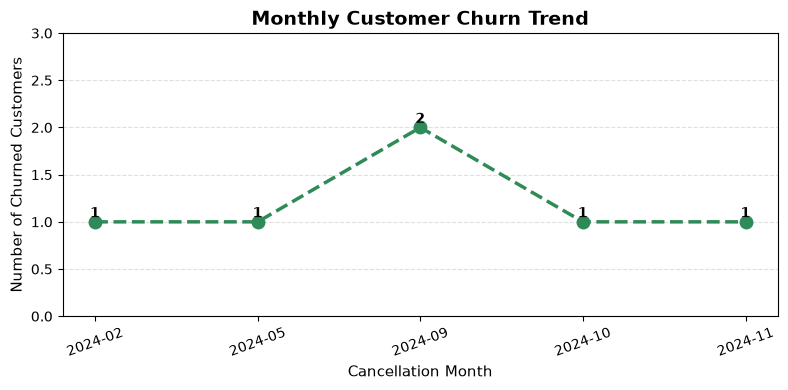

In [70]:
# 4.1 Monthly Customer Churn Trend (Time Series KPI)

# Extract cancellation month from cancellation date
df_visual["cancellation_month"] = (df_visual["cancellation_date"].dt.to_period("M"))

# Count churned customers month-wise
churn_trend = (df_visual[df_visual["churn_flag"] == 1].groupby("cancellation_month").size())

# Verification
# print(churn_trend)

# Create Figure
plt.figure(figsize=(8,4))

# Create Line Chart
plt.plot(churn_trend.index.astype(str), churn_trend.values, color="#2E8B57", marker="o", markersize=9, linewidth=2.5, linestyle="--")

# Add value labels
for x, y in zip(churn_trend.index.astype(str), churn_trend.values):
    plt.text(x, y + 0.05, str(y), ha="center", fontsize=10, fontweight="bold")

# Chart Formatting
plt.title("Monthly Customer Churn Trend", fontsize=14, fontweight="bold")
plt.xlabel("Cancellation Month", fontsize=11)
plt.ylabel("Number of Churned Customers", fontsize=11)
plt.xticks(rotation=20)
plt.ylim(0, churn_trend.max() + 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

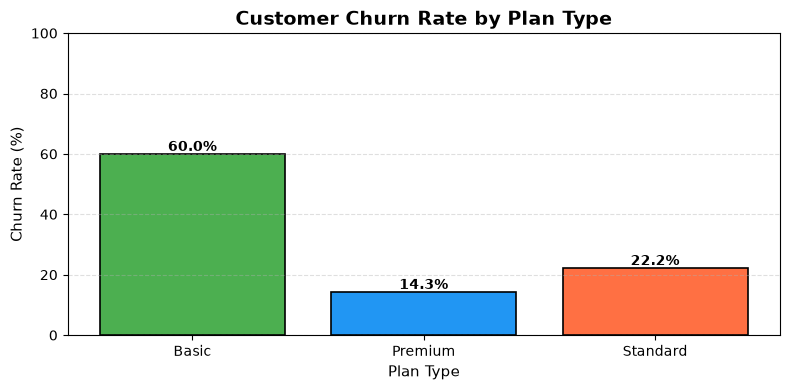

In [71]:
# 4.2 Churn by plan type

# Calculate churn rate by plan type
churn_plan = (df_visual.groupby("plan_type")["churn_flag"].mean().mul(100).round(2))

# Verification
# print(churn_plan)

# Create Figure
plt.figure(figsize=(8,4))

# Create Bar Chart
bars = plt.bar(churn_plan.index, churn_plan.values, color=["#4CAF50", "#2196F3", "#FF7043"], edgecolor="black", linewidth=1.2)

# Add percentage labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.1f}%", ha="center", fontsize=10, fontweight="bold")

# Chart Formatting
plt.title("Customer Churn Rate by Plan Type", fontsize=14, fontweight="bold")
plt.xlabel("Plan Type", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.ylim(0,100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

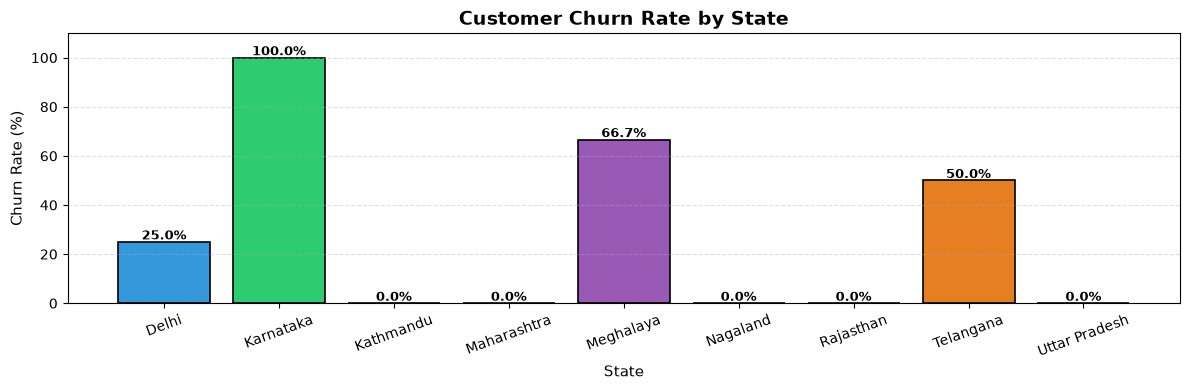

In [72]:
# 4.3 Churn Rate by State

# Calculate churn rate by state
churn_state = (df_visual.groupby("state")["churn_flag"].mean().mul(100).round(2))

# Verification
# print(churn_state)

# Create Figure
plt.figure(figsize=(12,4))

# Create Bar Chart
bars = plt.bar(churn_state.index, churn_state.values, color=[
        "#3498DB",  # Blue
        "#2ECC71",  # Green
        "#F39C12",  # Orange
        "#E74C3C",  # Red
        "#9B59B6",  # Purple
        "#1ABC9C",  # Turquoise
        "#F1C40F",  # Yellow
        "#E67E22",  # Dark Orange
        "#34495E"   # Dark Blue
    ],
edgecolor="black", linewidth=1.2)

# Add percentage labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.1f}%", ha="center", fontsize=9, fontweight="bold")

# Chart Formatting
plt.title("Customer Churn Rate by State", fontsize=14, fontweight="bold")
plt.xlabel("State", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.xticks(rotation=20)
plt.ylim(0,110)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [73]:
# 5. Visualaization using Seaborn

In [74]:
# Convert str to numeric so that we can find corr between feature

df[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations', 'churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,Low
1,Premium,Annual,91,1,1,High
2,Basic,Monthly,34,0,0,Low
3,Premium,Annual,8,0,0,Low
4,Standard,Monthly,88,1,1,High


In [75]:
# Correct Method of Encoding categorical variables based on business priority

# Create a copy of required columns
df_encoded = df_visual[[ "plan_type", "contract_type", "churn_score", "churn_flag", "escalations", "churn_risk" ]].copy()

# Define business priority
order_mappings = {
    "plan_type": ["Basic", "Standard", "Premium"],
    "contract_type": ["Monthly", "Annual"],
    "churn_risk": ["Low", "Medium", "High"]
}

# Encode categorical columns
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

# Verification
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


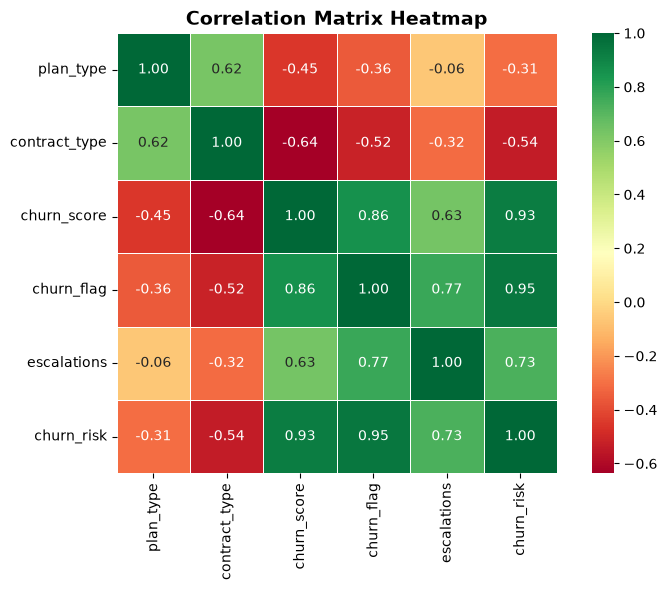

In [76]:
# 5.1 Heatmap (Correlation matrix?)

# Correlation Matrix
corr_matrix = df_encoded.corr()

# Create Figure
plt.figure(figsize=(8,6))

# Create Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5, square=True)

# Chart Formatting
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

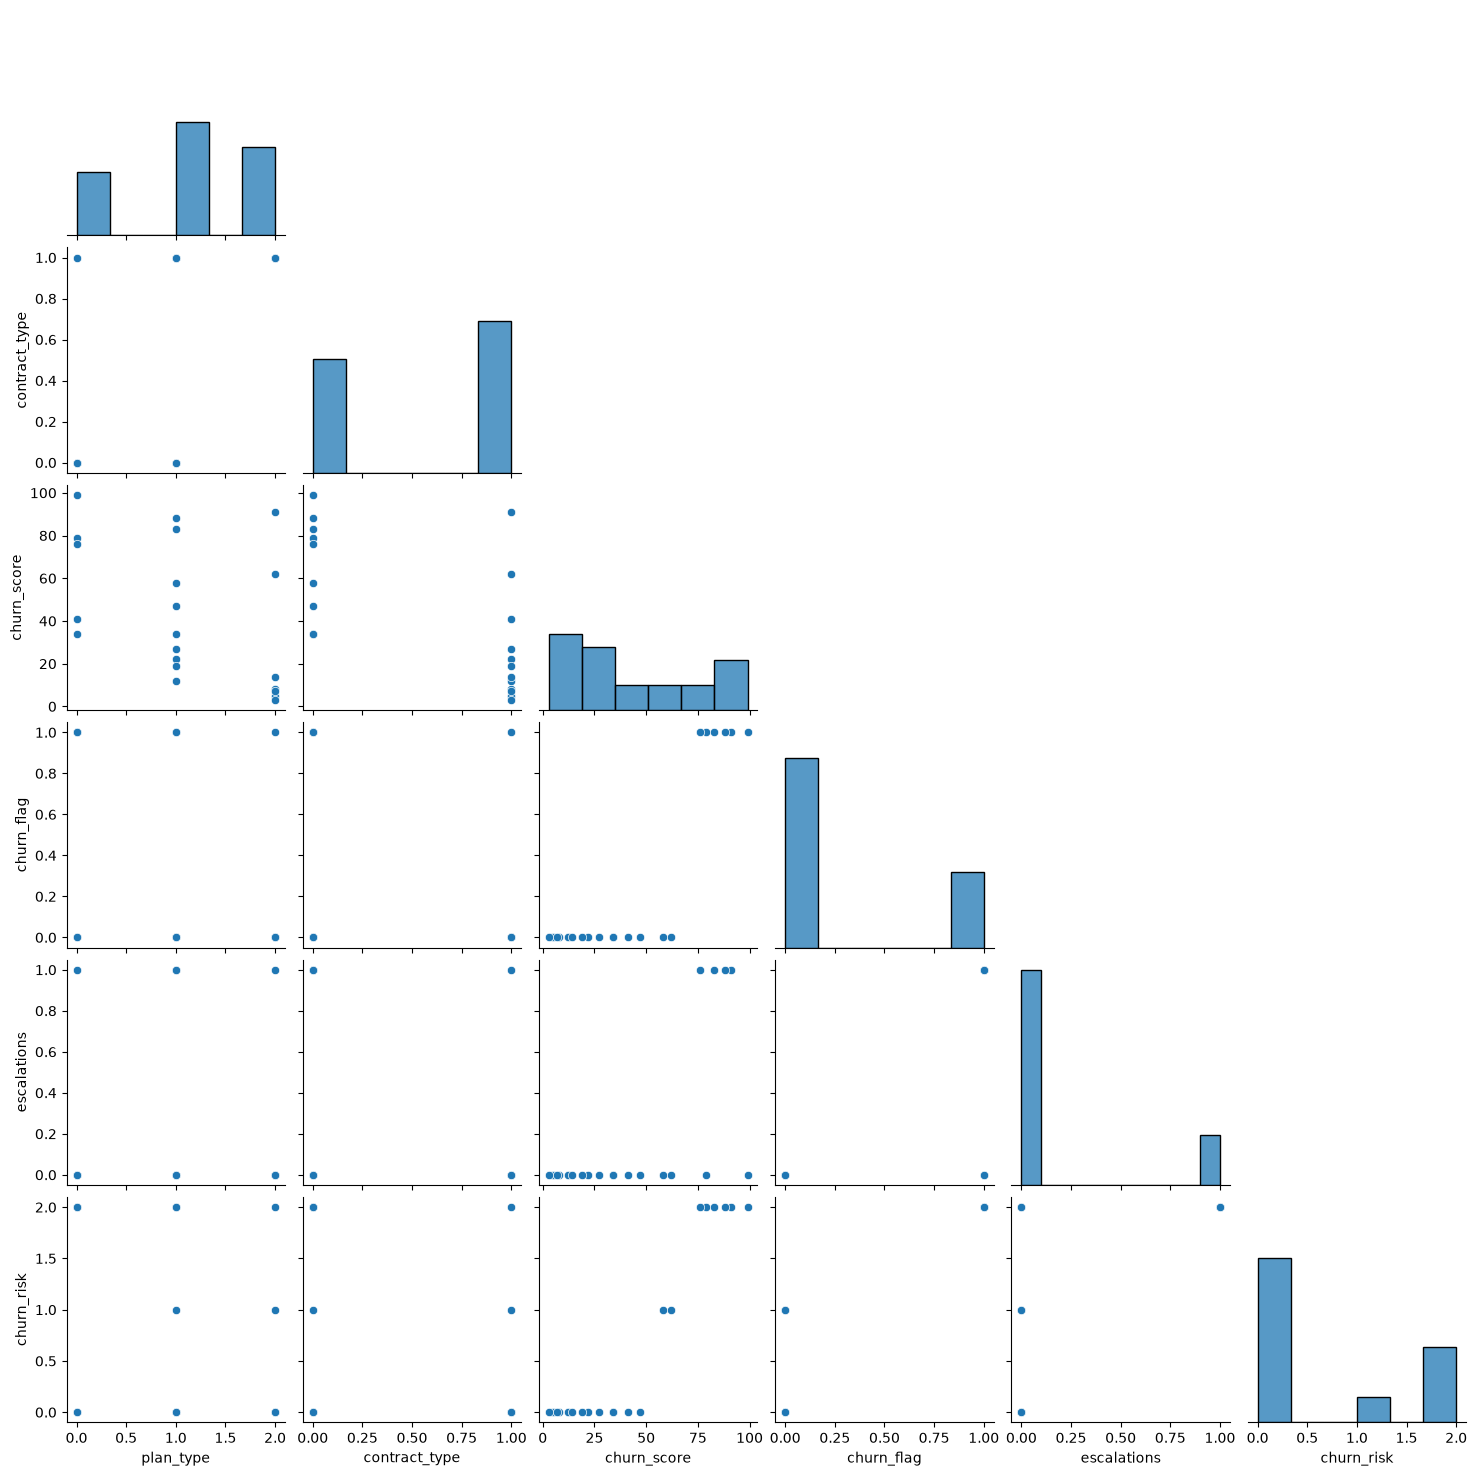

In [77]:
# 5.2 Pairplot - relationship in dataset

# Create Pair Plot
sns.pairplot(df_encoded, diag_kind="hist", corner=True, )

plt.show()

  plan_type  monthly_charges  gender churn_risk
0  Standard            13.99    Male        Low
1   Premium            12.99    Male       High
2     Basic             6.99  Female        Low
3   Premium            22.99    Male        Low
4  Standard            13.99  Female       High


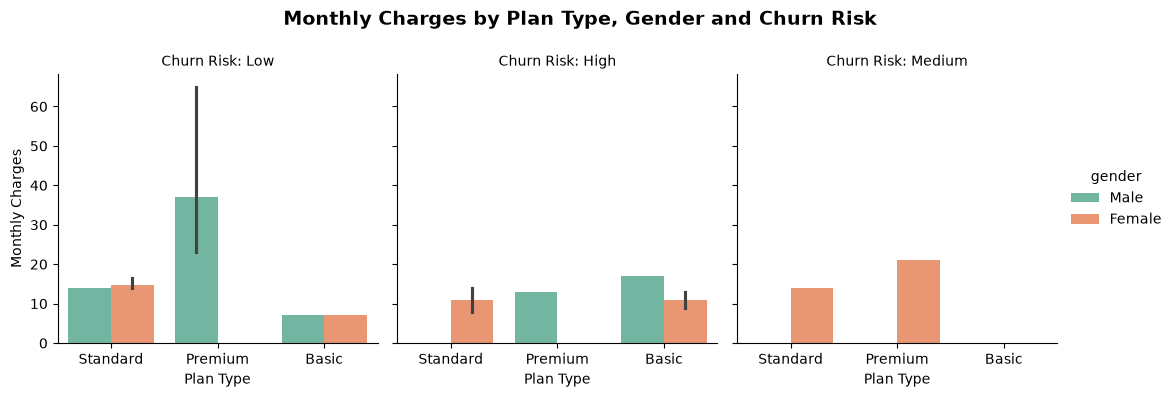

In [78]:
# 5.3 Categorical Plot (FacetGrid) -  multi-dim comparison

# Verification
print(df_visual[
        ["plan_type", "monthly_charges", "gender", "churn_risk"]
    ].head())

# Create CatPlot
g = sns.catplot(
    data=df_visual,
    x="plan_type",
    y="monthly_charges",
    hue="gender",
    col="churn_risk",
    kind="bar",
    palette="Set2",
    height=4,
    aspect=0.9
)

# Formatting
g.set_axis_labels("Plan Type", "Monthly Charges")
g.set_titles("Churn Risk: {col_name}")
g.fig.suptitle("Monthly Charges by Plan Type, Gender and Churn Risk", fontsize=14, fontweight="bold")
g.fig.subplots_adjust(top=0.82)
plt.show()

   tenure_days  churn_flag
0       1953.0           0
1       1501.0           1
2       1338.0           0
3       2628.0           0
4        419.0           1


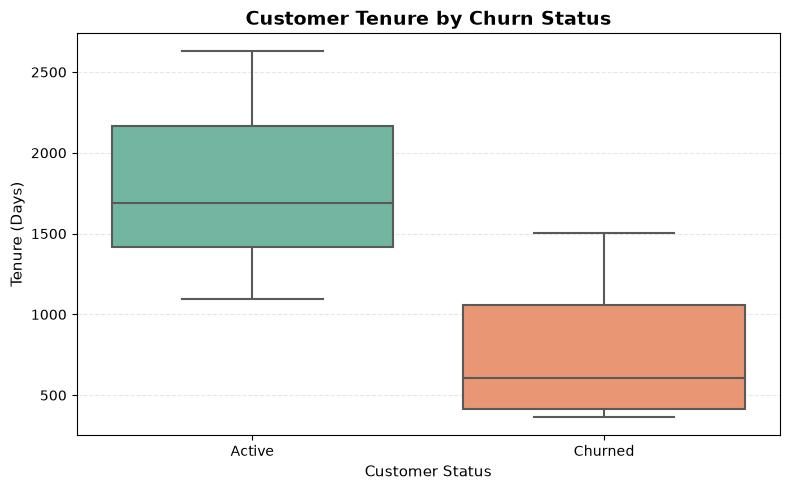

In [79]:
# 5.4 Customer Tenure vs Churn

# Verification
print(df_visual[["tenure_days", "churn_flag"]].head())

# Create Figure
plt.figure(figsize=(8,5))

# Create the box plot
sns.boxplot(
    data=df_visual,
    x="churn_flag",
    y="tenure_days",
    hue="churn_flag",
    palette="Set2",
    linewidth=1.5,
    legend=False
)

# Chart Formatting
plt.title("Customer Tenure by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status", fontsize=11)
plt.ylabel("Tenure (Days)", fontsize=11)
plt.xticks([0,1], ["Active","Churned"])
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

    csat_score  churn_flag
1         10.0           1
4         20.0           1
5         90.0           0
6         30.0           1
11        25.0           1


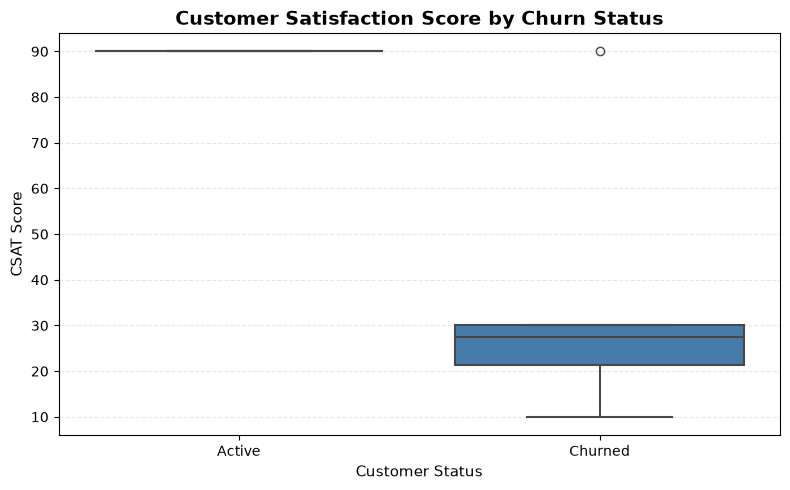

In [80]:
# 5.5 CSAT Score vs Churn

# Remove customers without CSAT score
csat_df = df_visual.dropna(subset=["csat_score"])

# Verification
print(csat_df[["csat_score", "churn_flag"]].head())

# Create Figure
plt.figure(figsize=(8,5))

# Create Box Plot
sns.boxplot(
    data=csat_df,
    x="churn_flag",
    y="csat_score",
    hue="churn_flag",
    palette="Set1",
    linewidth=1.5,
    legend=False
)

# Chart Formatting
plt.title("Customer Satisfaction Score by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status", fontsize=11)
plt.ylabel("CSAT Score", fontsize=11)
plt.xticks([0,1],
["Active","Churned"])
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
# 6. Pivot Table

In [82]:
pd.pivot_table(
    df_visual,
    values= "churn_flag",
    index= "plan_type",
    aggfunc= "mean"
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [83]:
pd.pivot_table(
    df_visual,
    index= "plan_type",
    values= "churn_flag",
    aggfunc= "mean"
).reset_index()  # use reset index for better aligment

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [84]:
pd.pivot_table(
    df_visual,
    index= "plan_type",
    values= ["monthly_charges","customerid","churn_flag"],
    aggfunc= {
        "monthly_charges" : "sum",
        "customerid" : "nunique",
        "churn_flag" : "mean"
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [85]:
# 7. Working with SQL in Python (pandas)

In [86]:
# Create database
conn = sqlite3.connect("test_database.sqlite")

# Remove old table
conn.execute("DROP TABLE IF EXISTS users")

# Create table
conn.execute("""
CREATE TABLE users (
    first_name TEXT,
    country TEXT,
    budget INTEGER
)
""")

# Save changes
conn.commit()

print("Table created successfully!")

Table created successfully!


In [87]:
# Insert Data

# Create Cursor
cursor = conn.cursor()

# Insert Multiple Records
cursor.execute("""
INSERT INTO users
VALUES
('Madhav', 'India', 2500),
('Rashmi', 'India', 4500),
('Aarav', 'India', 3200),
('John', 'USA', 6000),
('Emma', 'USA', 5500),
('Olivia', 'Canada', 4800),
('Liam', 'Canada', 5100),
('Noah', 'Australia', 4200),
('Sophia', 'Australia', 3900),
('Raj', 'India', 2800)
""")

# Save Changes
conn.commit()

print("10 Records Inserted Successfully!")

10 Records Inserted Successfully!


In [88]:
# check inserted data in table

# Connect to database
conn = sqlite3.connect("test_database.sqlite")

# SQL Query
query = "SELECT * FROM users"

# Read data into DataFrame
df_results = pd.read_sql(query, conn)

# Display first 5 rows
df_results

,first_name,country,budget
0,Madhav,India,2500
1,Rashmi,India,4500
2,Aarav,India,3200
3,John,USA,6000
4,Emma,USA,5500
5,Olivia,Canada,4800
6,Liam,Canada,5100
7,Noah,Australia,4200
8,Sophia,Australia,3900
9,Raj,India,2800


In [89]:
# Aggregation

query = """
SELECT
    country,
    SUM(budget) AS total_budget
FROM users
GROUP BY country
"""

df_agg = pd.read_sql(query, conn)

df_agg

,country,total_budget
0,Australia,8100
1,Canada,9900
2,India,13000
3,USA,11500


In [90]:
# always close the connection after use

conn.close()

In [ ]:
### Business Insights & Recommendations

In [ ]:
## Insights
# • Churn Rate: 28.6% | Retention Rate: 71.4%
# • Most of the churn is from basic subscription plan – nothing to worry in terms of major revenue impact
# • Most of the churn happened in the month of Sep 2024 and, most affected state is Karnataka
# • Average Tenure (Days): 1,451 | ARPU is Rs 18.8
# • Total Revenue = 395
# • Revenue loss due to churn = 74 | CLTV Lost = 2,047
# • % Revenue loss = 18%
# • monthly vs annual churn = 55.6% vs 8.3%

In [ ]:
## Action Items
# • Check what happened in Karnataka – was there any increase in price, user complaints, tech issues, etc
# • Did we increased subs price for Basic plan or recently made any changes – specially in sep month?
# • Check what competitor is doing – bcoz one user has moved to competitor
# • Focus on customers with ‘High’ & ‘Med’ churn risk, check their LTV (to make priority list), complaint request, reach out to 
# them through email, sms, calls and fix their issue.

In [92]:
# To restore the default settings later for display

# pd.reset_option("display.max_rows")
# pd.reset_option("display.max_columns")